# Dataset Extraction: Bitcoin (BTC-USD)

In [1]:

# Time period: August 2014 to December 2025

import yfinance as yf
import pandas as pd

# Define ticker and date range
ticker = "BTC-USD"
start_date = "2014-08-01"
end_date = "2025-12-31"

# Download data
df = yf.download(ticker, start=start_date, end=end_date)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Save to CSV
file_name = "BTC_USD_Aug2014_Dec2025.csv"
df.to_csv(file_name, index=False)

# Basic info check
print("Dataset downloaded successfully!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Shape:", df.shape)
print(df.head())


/tmp/ipykernel_4359/1526363275.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Dataset downloaded successfully!
Date range: 2014-09-17 00:00:00 to 2025-12-30 00:00:00
Shape: (4123, 6)
Price        Date       Close        High         Low        Open    Volume
Ticker                BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
0      2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
1      2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2      2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
3      2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
4      2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100


Load Dataset & Basic Inspection

In [2]:
import pandas as pd


# Load CSV, skip the second header row
df = pd.read_csv(
    "BTC_USD_Aug2014_Dec2025.csv",
    skiprows=[1]  # removes the BTC-USD row
)

# Rename columns cleanly (safety)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Sort data by date (important for time-series analysis)
df = df.sort_values("Date").reset_index(drop=True)

# Drop missing values
df = df.dropna()

print(df.head())
print(df.info())


        Date       Close        High         Low        Open    Volume
0 2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
1 2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2 2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
3 2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
4 2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4123 non-null   datetime64[ns]
 1   Close   4123 non-null   float64       
 2   High    4123 non-null   float64       
 3   Low     4123 non-null   float64       
 4   Open    4123 non-null   float64       
 5   Volume  4123 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 193.4 KB
None


Missing Values & Data Quality Check

In [3]:
# Check missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

# If needed (usually Yahoo Finance is clean)
df = df.dropna()


Missing values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Exploratory Data Analysis

Time Series Plot (Close Price)

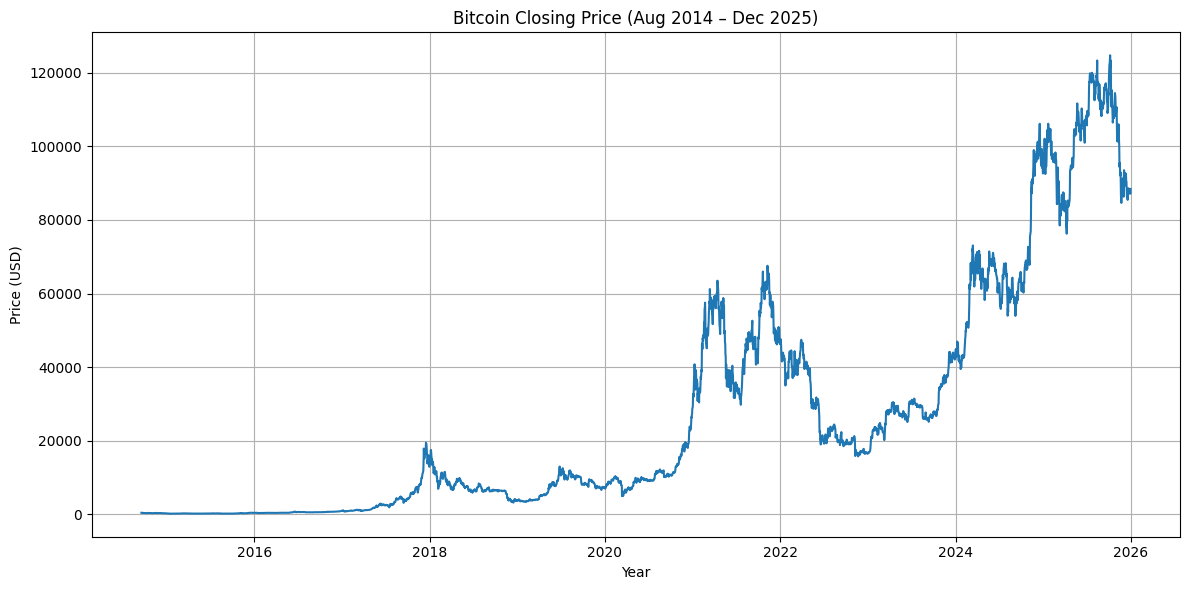

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Bitcoin Closing Price (Aug 2014 – Dec 2025)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.grid(True)
plt.show()


Feature Distribution

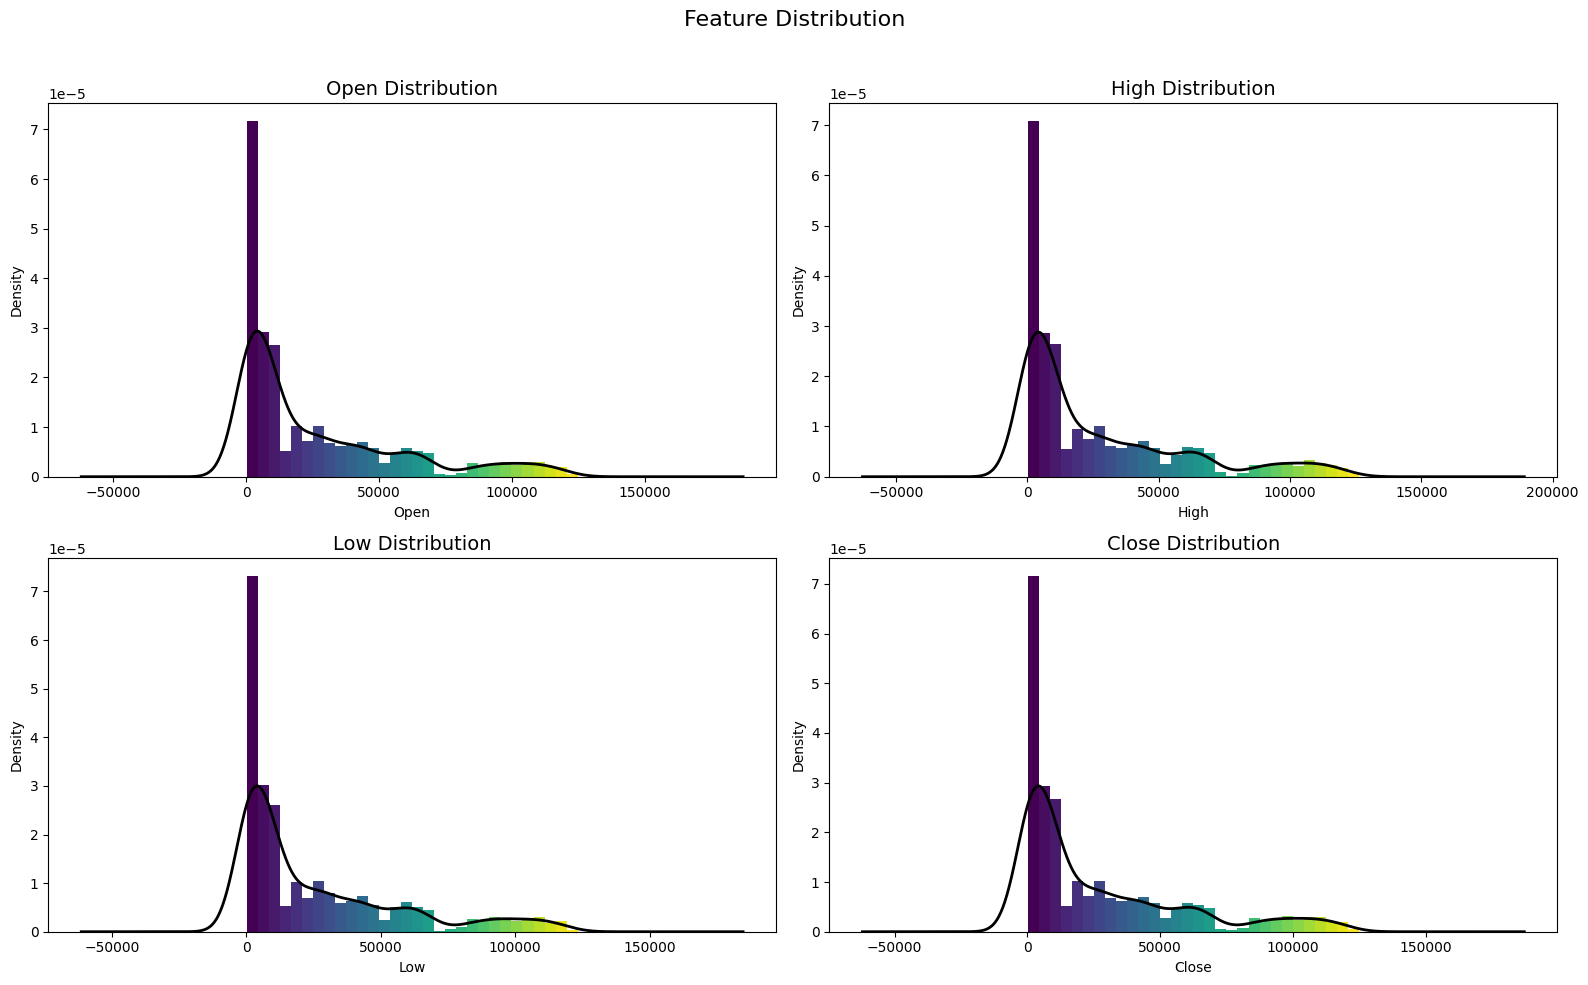

In [11]:
import numpy as np

features = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(16, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)

    # Histogram values
    counts, bins = np.histogram(df[col], bins=30, density=True)

    # Create gradient colors
    colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))

    # Plot bars manually for gradient effect
    for j in range(len(counts)):
        plt.bar(bins[j], counts[j],
                width=bins[j+1] - bins[j],
                color=colors[j],
                align='edge')

    # Smooth density curve
    df[col].plot(kind='kde', color='black', linewidth=2)

    # Titles
    plt.title(f"{col} Distribution", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.grid(False)

plt.suptitle("Feature Distribution", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Box Plots – ALL Features (Outliers & Spread)

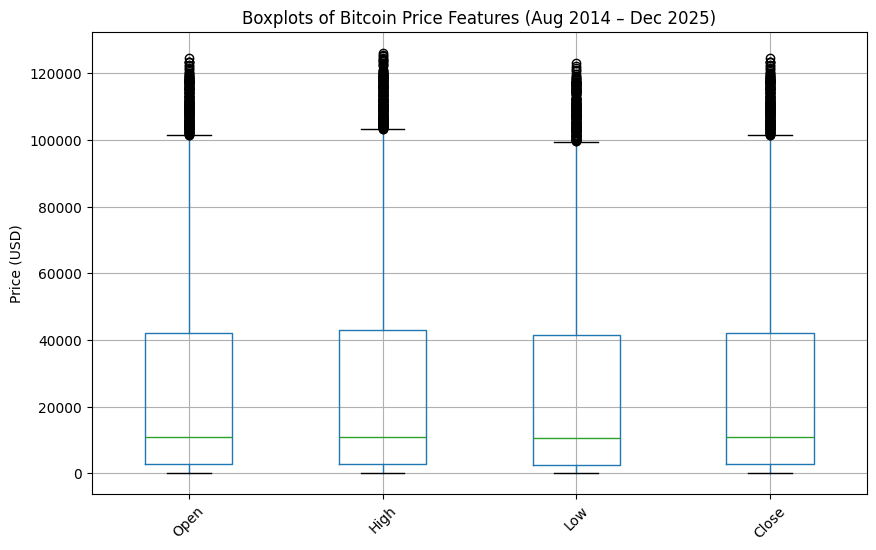

In [16]:
features = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(10,6))
df[features].boxplot()

plt.title("Boxplots of Bitcoin Price Features (Aug 2014 – Dec 2025)")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

There are so many outliers in the data which means that the prices of the stock have varied hugely in a very short period of time.Let's check this with the help of a barplot.


#Feature Engineering

Feature Engineering helps to derive some valuable features from the existing ones. These extra features sometimes help in increasing the performance of the model significantly and certainly help to gain deeper insights into the data.

In [14]:
# Extract Year, Month, and Day from Date
# Feature engineering from Date
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df.head()

,Date,Close,High,Low,Open,Volume,year,month,day
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,2014,9,17
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,2014,9,18
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,2014,9,19
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,2014,9,20
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,2014,9,21


Year-wise Aggregation (Mean Prices)

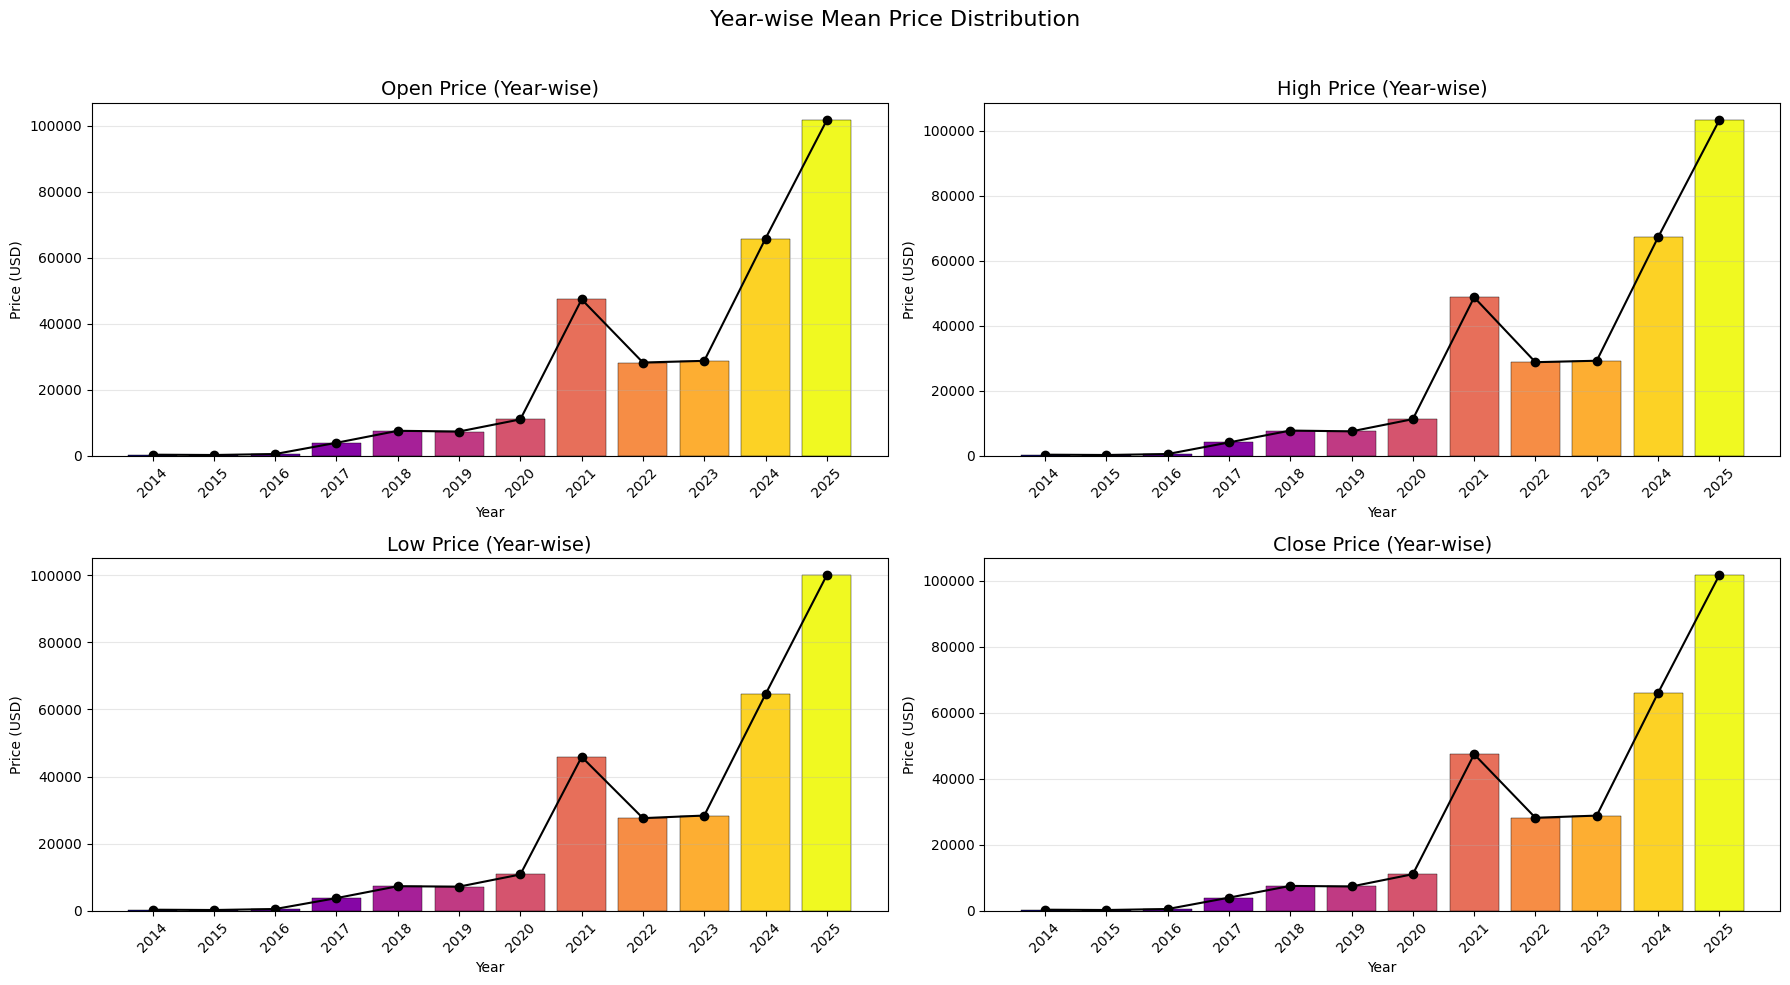

In [18]:
# Group by year and calculate mean
data_grouped = df.groupby('year')[['Open', 'High', 'Low', 'Close']].mean()

plt.figure(figsize=(18, 10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close'], 1):
    plt.subplot(2, 2, i)

    values = data_grouped[col].values
    years = data_grouped.index.astype(str)

    # Create gradient colors
    colors = plt.cm.plasma(np.linspace(0, 1, len(values)))

    # Bar plot with gradient
    bars = plt.bar(years, values, color=colors, edgecolor='black', linewidth=0.3)

    # Smooth line overlay
    plt.plot(years, values, color='black', linewidth=1.5, marker='o')

    # Titles and labels
    plt.title(f"{col} Price (Year-wise)", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Price (USD)")

    # Clean look
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

plt.suptitle("Year-wise Mean Price Distribution", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The year-wise mean price analysis reveals a sharp increase in Bitcoin prices from 2020 onwards, with a significant price surge observed during 2021 and subsequent years. This rapid growth explains the presence of extreme outliers identified in the box plots and distribution analysis. The results indicate that these outliers are not data errors but reflect genuine market behaviour driven by large-scale price appreciation.

Correlation Heatmap (Price Features)

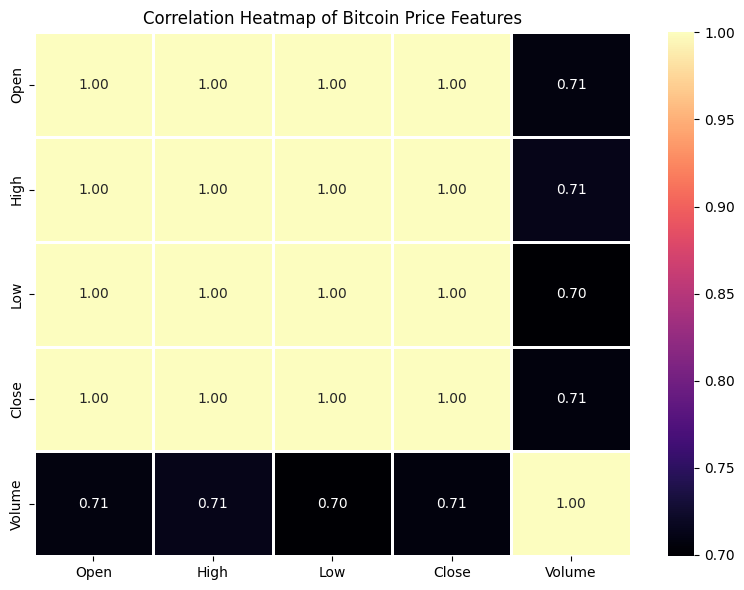

In [22]:
import seaborn as sns

# Select relevant numerical features
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Compute correlation matrix
corr_matrix = df[features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.8
)

plt.title("Correlation Heatmap of Bitcoin Price Features")
plt.tight_layout()
plt.show()


The correlation heatmap shows near-perfect positive correlations among Open, High, Low, and Close prices, indicating strong multicollinearity between price-based features. This behaviour is expected in financial time-series data, as these variables represent different price points within the same trading period. Trading volume exhibits a comparatively lower correlation with price features, suggesting that it may provide complementary market activity information rather than direct price dependence.

Bitcoin Close Price Distribution with Mean & Median (2014–2025)

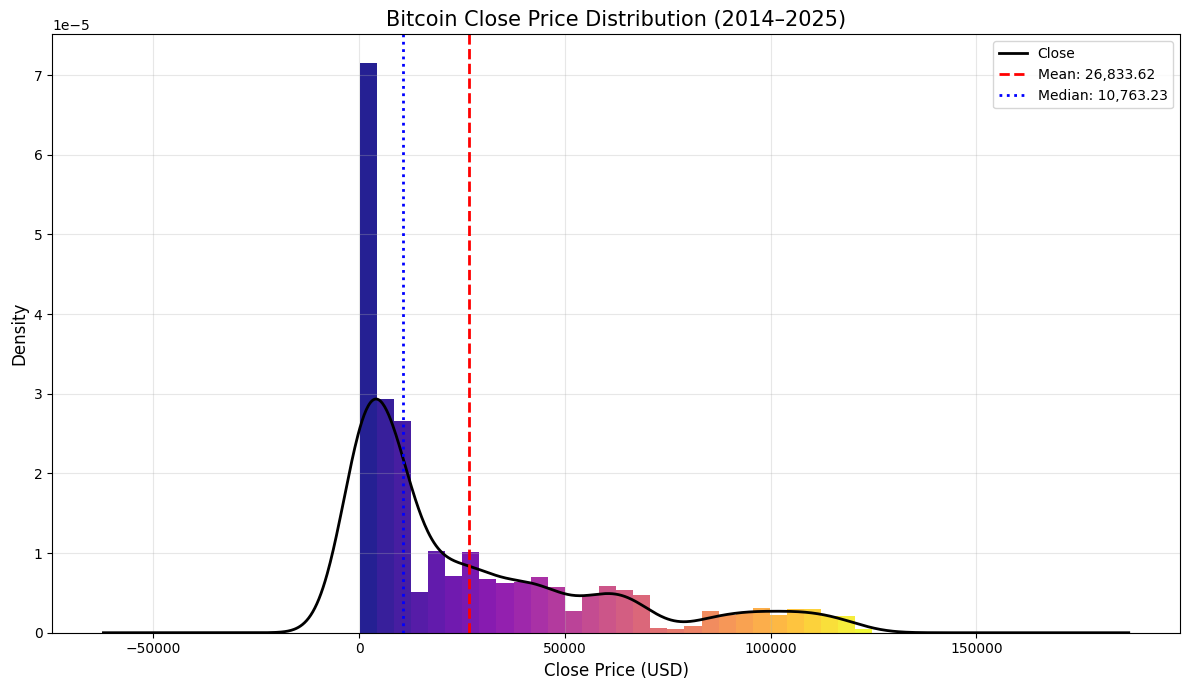

In [25]:
mean_close = df['Close'].mean()
median_close = df['Close'].median()

plt.figure(figsize=(12, 7))

# Histogram values
counts, bins = np.histogram(df['Close'], bins=30, density=True)

# Gradient colors
colors = plt.cm.plasma(np.linspace(0, 1, len(counts)))

# Plot gradient bars
for i in range(len(counts)):
    plt.bar(bins[i], counts[i],
            width=bins[i+1] - bins[i],
            color=colors[i],
            align='edge',
            alpha=0.9)

# KDE curve
df['Close'].plot(kind='kde', color='black', linewidth=2)

# Mean & Median lines
plt.axvline(mean_close, color='red', linestyle='--', linewidth=2,
            label=f"Mean: {mean_close:,.2f}")

plt.axvline(median_close, color='blue', linestyle=':', linewidth=2,
            label=f"Median: {median_close:,.2f}")

# Titles & labels
plt.title("Bitcoin Close Price Distribution (2014–2025)", fontsize=15)
plt.xlabel("Close Price (USD)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Clean styling
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Year-wise Mean Bitcoin Close Price (2014–2025)

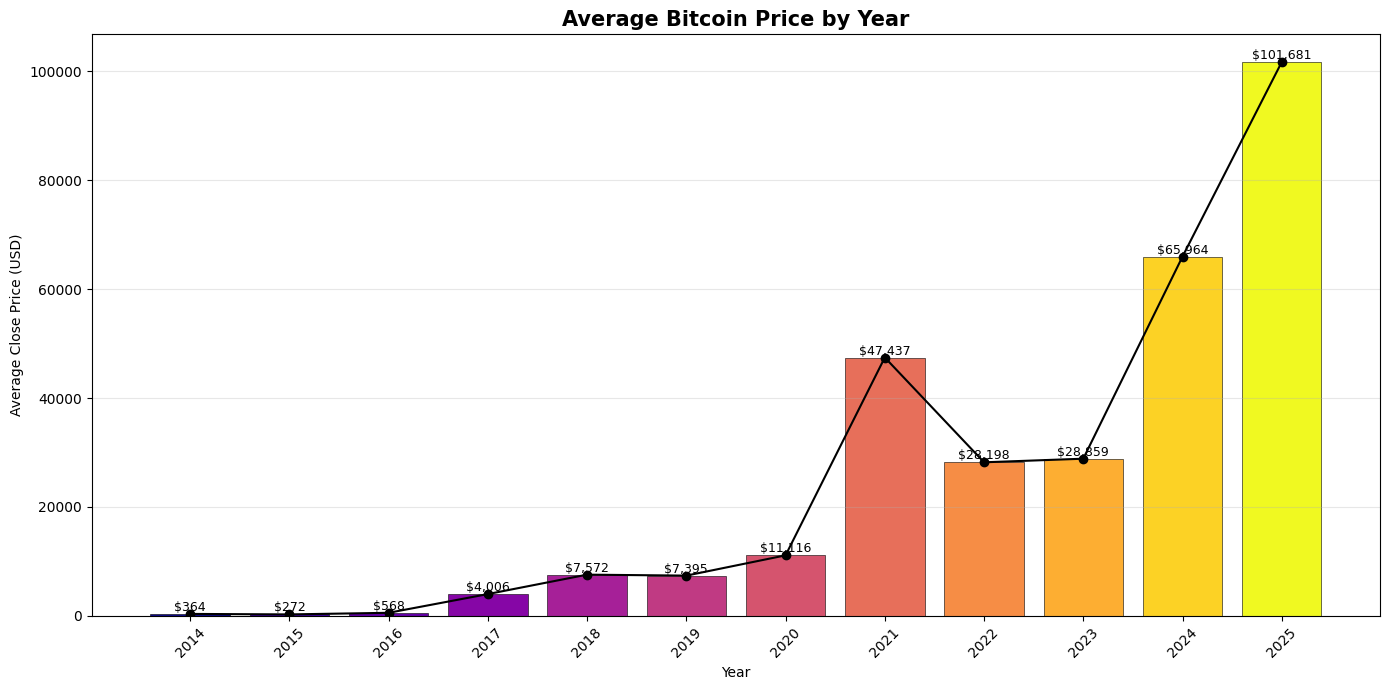

In [26]:
# Extract Year
df['Year'] = df['Date'].dt.year

# Yearly mean
yearly_mean_close = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(14, 7))

years = yearly_mean_close.index.astype(str)
values = yearly_mean_close.values

# Gradient colors
colors = plt.cm.plasma(np.linspace(0, 1, len(values)))

# Bar plot
bars = plt.bar(years, values, color=colors, edgecolor='black', linewidth=0.4)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.plot(years, values, color='black', marker='o', linewidth=1.5)

# Titles & labels
plt.title("Average Bitcoin Price by Year", fontsize=15, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Average Close Price (USD)")

# Clean styling
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Import Libraries for LSTM Model

In [27]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import tensorflow as tf
import random
import os

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

Prepare Data

In [28]:
# Close price
data = df[['Close']].values

# Initialize MinMaxScaler to normalize the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

Create Time Sequences (Lookback = 60 Days)

In [29]:
# Function to create sequences for time series forecasting
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Number of previous days used to predict the next value
lookback = 60

# Create input-output sequences from the scaled data
X, y = create_sequences(scaled_data, lookback)

# Reshape for LSTM [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

Train-Test Split (80% Train, 20% Test)

In [30]:
# Split the dataset into training and testing sets
# Calculate the index for 80% of the dataset
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Build LSTM Model

In [31]:
# Initialize the Sequential model
model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))

# Dropout layer to prevent overfitting
# seed ensures reproducibility
model.add(Dropout(0.2, seed=42))

# Second LSTM layer
model.add(LSTM(units=50))

# Another dropout layer for regularization
model.add(Dropout(0.2, seed=42))

# Dense output layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [32]:
# Train the LSTM model using the training dataset
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32, # Number of samples
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.8704e-04 - val_loss: 0.0030
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.7737e-04 - val_loss: 0.0030
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.3308e-04 - val_loss: 0.0020
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.1316e-04 - val_loss: 0.0043
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 3.5473e-04 - val_loss: 0.0014
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.4147e-04 - val_loss: 0.0015
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.1854e-04 - val_loss: 9.9956e-04
Epoch 9/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.1184e-04 - val_loss: 0.0021
Epoch 10/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7179e-04 - val_loss: 0.0014
Epoch 11/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6401e-04 - val_loss: 7.49

LSTM Epoch Plot (Training vs Validation Loss)

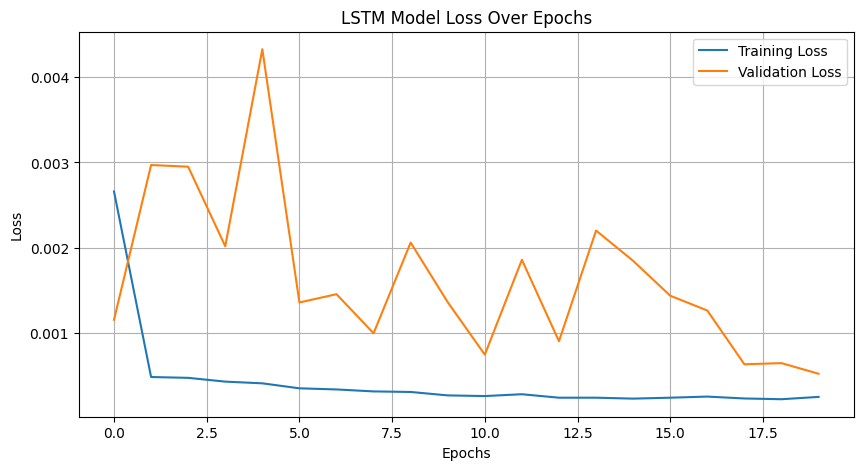

In [33]:
# Plot LSTM training history
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

Make Predictions

In [34]:
# Generate predictions
predictions = model.predict(X_test)

# Inverse scale
# Convert the predicted values back to the original price scale
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Evaluation Metrics

In [35]:
# Calculate evaluation metrics to measure the performance of the LSTM model
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions)) # Root Mean Squared Error (RMSE)
mae = mean_absolute_error(y_test_actual, predictions) # Mean Absolute Error (MAE)
r2 = r2_score(y_test_actual, predictions) # R-squared (Coefficient of Determination)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100 # Mean Absolute Percentage Error (MAPE)

print("LSTM Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)

LSTM Results
RMSE: 2855.4672529953964
MAE: 2216.303846671279
R2: 0.9873789362429625
MAPE: 3.0192883273958935


Plot Actual vs Predicted

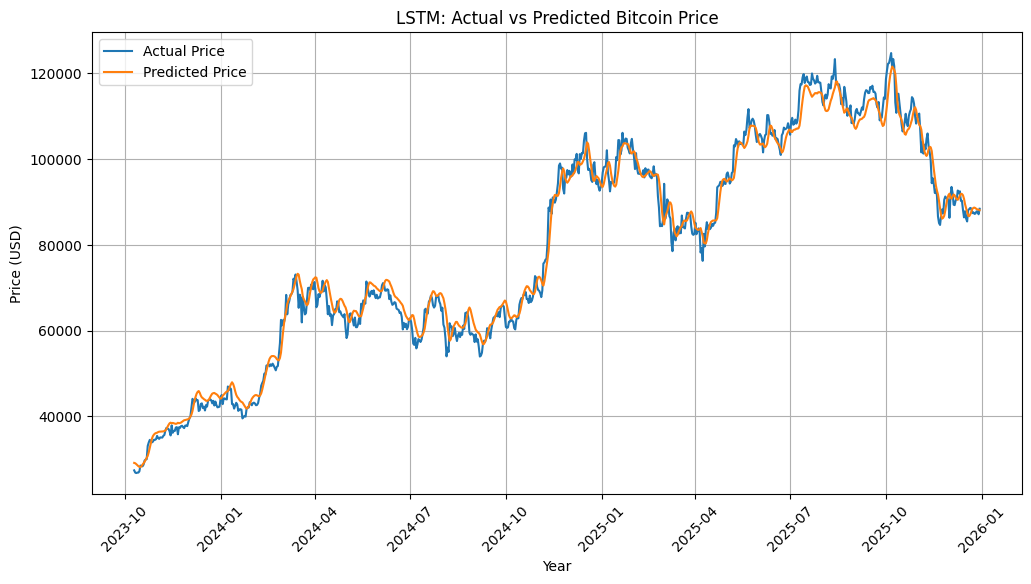

In [36]:
# Extract the corresponding dates for the test dataset
test_dates = df['Date'][-len(y_test_actual):]

plt.figure(figsize=(12,6))

# Plot the actual Bitcoin prices from the test dataset
plt.plot(test_dates, y_test_actual, label='Actual Price')

# Plot the predicted Bitcoin prices generated by the LSTM model
plt.plot(test_dates, predictions, label='Predicted Price')

plt.title("LSTM: Actual vs Predicted Bitcoin Price")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

LSTM captures long-term dependencies in sequential financial data and overcomes vanishing gradient issues present in traditional RNNs.

Define Forecast Horizon

In [37]:
# Number of future days (3 months = 90 days)
future_days = 90

Use Last 60 Days as Initial Input

In [38]:
# Get the last 60 days from scaled data
last_sequence = scaled_data[-lookback:]

Recursive Forecasting Loop

In [39]:
# Create an empty list to store future predicted values
future_predictions = []

# Copy the last 60 days sequence
current_sequence = last_sequence.copy()

# Generate predictions
for _ in range(future_days):

    # Reshape for model
    input_seq = current_sequence.reshape(1, lookback, 1)

    # Predict next value
    next_pred = model.predict(input_seq, verbose=0)

    # Store prediction
    future_predictions.append(next_pred[0,0])

    # Update sequence
    current_sequence = np.append(current_sequence[1:], next_pred)

# Convert to array
future_predictions = np.array(future_predictions).reshape(-1,1)

# Inverse scale
future_predictions = scaler.inverse_transform(future_predictions)

Create Future Date Index

In [40]:
# Last date in dataset
last_date = df['Date'].iloc[-1]

# Create future dates
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=future_days)

Plot Forecast

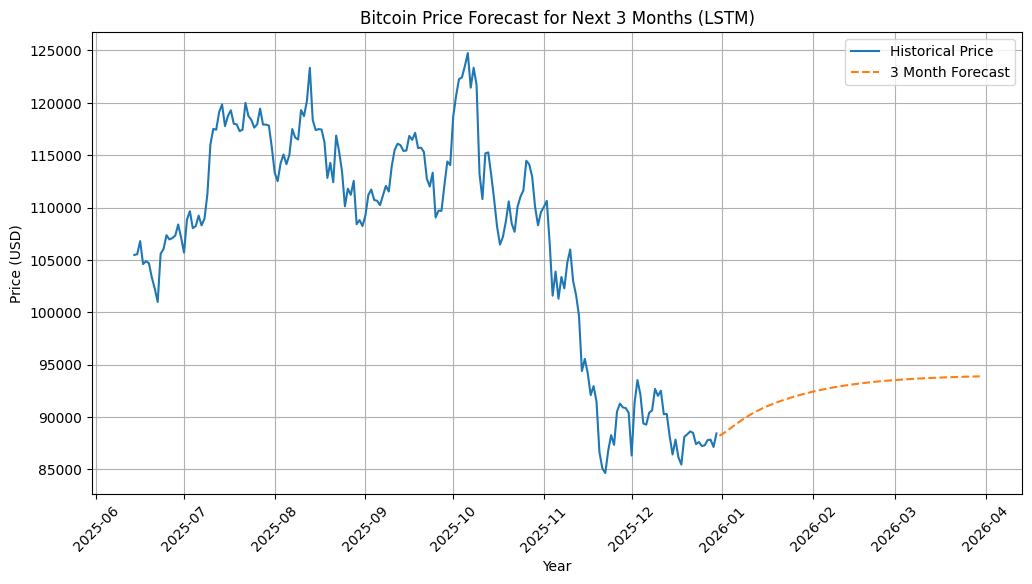

In [41]:
plt.figure(figsize=(12,6))

# Historical data (last 200 days for clarity)
plt.plot(df['Date'][-200:], df['Close'][-200:], label="Historical Price")

# Forecast
plt.plot(future_dates, future_predictions, label="3 Month Forecast", linestyle='--')

plt.title("Bitcoin Price Forecast for Next 3 Months (LSTM)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.show()

1-Year Bitcoin Forecast (LSTM)

In [42]:
# Number of days for 1 year forecast
future_days_1y = 365

# Take last 60 days again
last_sequence_1y = scaled_data[-lookback:]

# Create a list to store
future_predictions_1y = []

# Copy the last sequence
current_sequence_1y = last_sequence_1y.copy()

# Generate predictions for the next 365 days
for _ in range(future_days_1y):

    # Reshape the input sequence
    input_seq = current_sequence_1y.reshape(1, lookback, 1)

    # Predict the next time step
    next_pred = model.predict(input_seq, verbose=0)

    # Store the predicted value
    future_predictions_1y.append(next_pred[0,0])

    # Update the input sequence for the next prediction
    current_sequence_1y = np.append(current_sequence_1y[1:], next_pred)

# Convert to array
future_predictions_1y = np.array(future_predictions_1y).reshape(-1,1)

# Inverse scaling - Convert values back to the original price scale
future_predictions_1y = scaler.inverse_transform(future_predictions_1y)

Create Future Dates (1 Year)

In [43]:
# Last date in dataset
last_date_1y = df['Date'].iloc[-1]

# Generate next 365 days
future_dates_1y = pd.date_range(start=last_date_1y + pd.Timedelta(days=1),
                                periods=future_days_1y)

Plot 1-Year Forecast

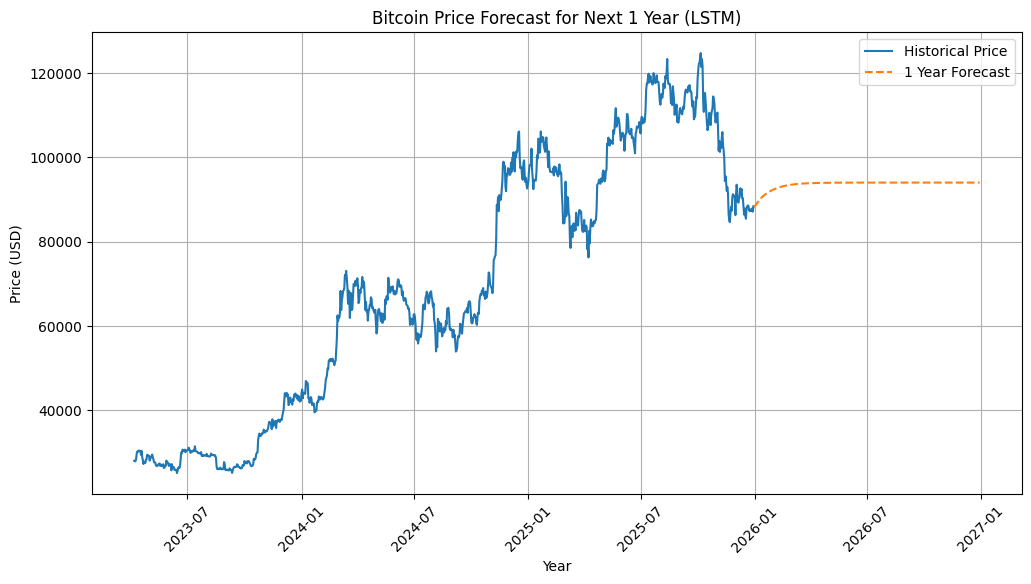

In [44]:
plt.figure(figsize=(12,6))

# Historical prices (last 1000 days)
plt.plot(df['Date'][-1000:], df['Close'][-1000:], label="Historical Price")

# Plot the predicted prices for the next 1 year
plt.plot(future_dates_1y, future_predictions_1y,
         label="1 Year Forecast",
         linestyle="--")

plt.title("Bitcoin Price Forecast for Next 1 Year (LSTM)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

TUNED LSTM MODEL

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

tuned_lstm = Sequential()

# First LSTM layer
tuned_lstm.add(LSTM(units=96, return_sequences=True, input_shape=(X_train.shape[1], 1)))
tuned_lstm.add(BatchNormalization())
tuned_lstm.add(Dropout(0.3))

# Second LSTM layer
tuned_lstm.add(LSTM(units=48, return_sequences=True))
tuned_lstm.add(BatchNormalization())
tuned_lstm.add(Dropout(0.3))

# Third LSTM layer
tuned_lstm.add(LSTM(units=32))
tuned_lstm.add(Dropout(0.2))

# Dense layers
tuned_lstm.add(Dense(25, activation='relu'))
tuned_lstm.add(Dense(1))

# Compile
tuned_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

tuned_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 96)         │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 48)         │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 48)         │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,267 (301.82 KB)

 Trainable params: 76,979 (300.70 KB)

 Non-trainable params: 288 (1.12 KB)

Train Model - TUNED LSTM

In [46]:
history_tuned = tuned_lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0137 - val_loss: 0.3284
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0036 - val_loss: 0.2400
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0023 - val_loss: 0.1925
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0018 - val_loss: 0.1546
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0014 - val_loss: 0.1195
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0013 - val_loss: 0.0879
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0011 - val_loss: 0.0563
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - val_loss: 0.0566
Epoch 9/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 7.8812e-04 - val_loss: 0.0441
Epoch 10/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 7.0713e-04 - val_loss: 0.0338
Epoch 11/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 7.0659e-04 - val_loss: 0.0373
Epoch 12/50
102/102 ━━━━━━━━━

Epoch Plot - TUNED LSTM

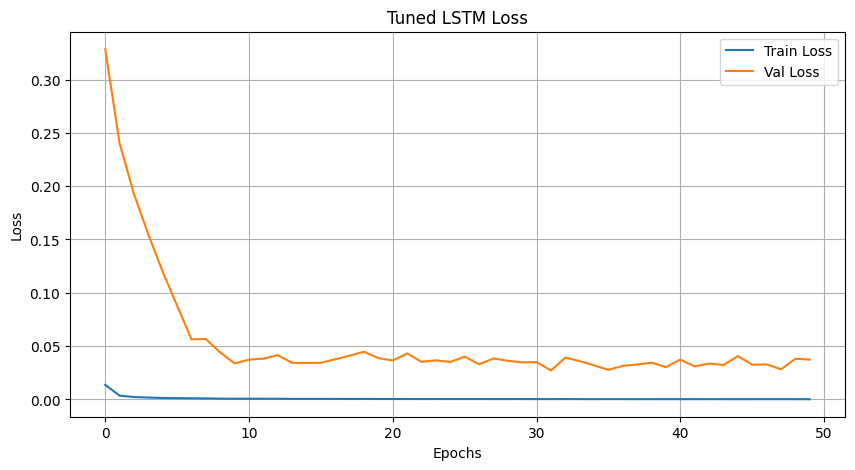

In [47]:
plt.figure(figsize=(10,5))

plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Val Loss')

plt.title('Tuned LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()

Predictions - TUNED LSTM

In [48]:
tuned_predictions = tuned_lstm.predict(X_test)

tuned_predictions = scaler.inverse_transform(tuned_predictions)
y_test_actual_tuned = scaler.inverse_transform(y_test.reshape(-1,1))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


Evaluation

In [49]:
rmse_tuned = np.sqrt(mean_squared_error(y_test_actual_tuned, tuned_predictions))
mae_tuned = mean_absolute_error(y_test_actual_tuned, tuned_predictions)
r2_tuned = r2_score(y_test_actual_tuned, tuned_predictions)
mape_tuned = np.mean(np.abs((y_test_actual_tuned - tuned_predictions) / y_test_actual_tuned)) * 100

print("Tuned LSTM Results")
print("RMSE:", rmse_tuned)
print("MAE:", mae_tuned)
print("R2:", r2_tuned)
print("MAPE:", mape_tuned)

Tuned LSTM Results
RMSE: 24091.985955798962
MAE: 18047.856489756305
R2: 0.10156472456440324
MAPE: 18.63070961222982


Actual vs Predicted - Tuned LSTM

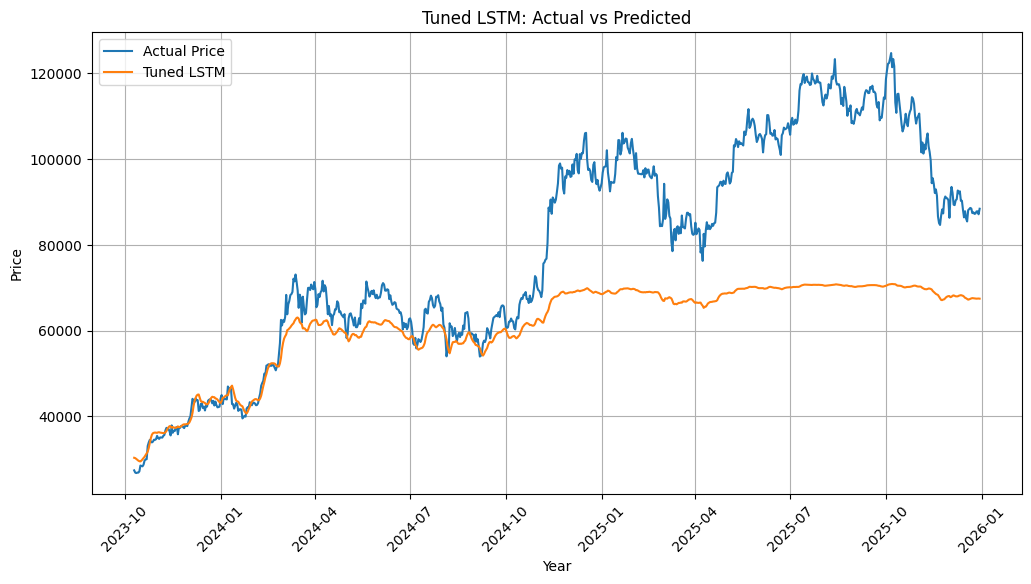

In [50]:
tuned_dates = df['Date'][-len(y_test_actual_tuned):]

plt.figure(figsize=(12,6))

plt.plot(tuned_dates, y_test_actual_tuned, label='Actual Price')
plt.plot(tuned_dates, tuned_predictions, label='Tuned LSTM')

plt.title("Tuned LSTM: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Price")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

GRU Model

In [51]:
# Import GRU layer
from tensorflow.keras.layers import GRU

# Build GRU model
gru_model = Sequential()

# First GRU layer
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1],1)))
gru_model.add(Dropout(0.3))

# Second GRU layer
gru_model.add(GRU(units=32))
gru_model.add(Dropout(0.3))

# Dense layers
gru_model.add(Dense(1))

# Compile model
gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Display architecture
gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

Train GRU Model

In [52]:
# Train GRU model
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=25,    # Number of times the model will iterate
    batch_size=32,  # Number of samples processed
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 2/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.0154e-04 - val_loss: 0.0026
Epoch 3/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4500e-04 - val_loss: 0.0012
Epoch 4/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.0365e-04 - val_loss: 8.3046e-04
Epoch 5/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.1756e-04 - val_loss: 4.9626e-04
Epoch 6/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 5.0105e-04 - val_loss: 6.8836e-04
Epoch 7/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0560e-04 - val_loss: 4.0143e-04
Epoch 8/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.6807e-04 - val_loss: 0.0012
Epoch 9/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3488e-04 - val_loss: 6.5961e-04
Epoch 10/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.3657e-04 - val_loss: 3.6987e-04
Epoch 11/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.1484e-0

GRU Epoch Plot (Training vs Validation Loss)

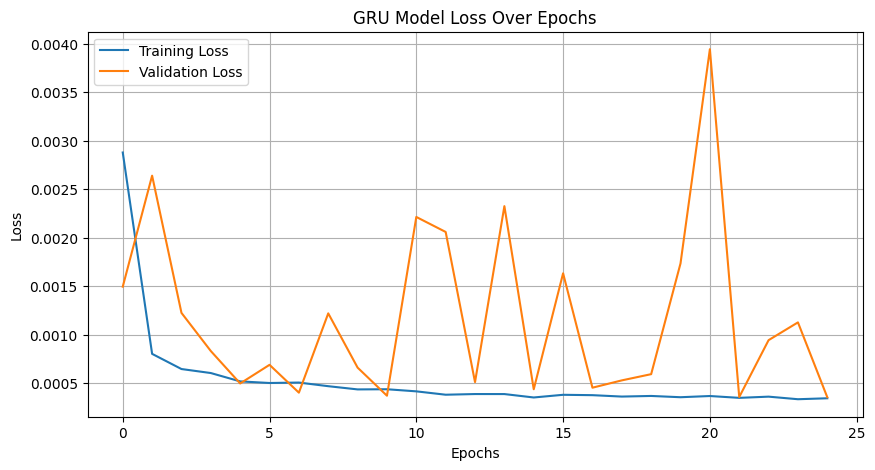

In [53]:
# Plot GRU training history
plt.figure(figsize=(10,5))

plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('GRU Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

GRU Predictions

In [54]:
# Predict using GRU model
gru_predictions = gru_model.predict(X_test)

# Convert predictions back to real price scale
gru_predictions = scaler.inverse_transform(gru_predictions)

# Convert actual values
y_test_actual_gru = scaler.inverse_transform(y_test.reshape(-1,1))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Evaluate GRU Model

In [55]:
# Evaluation metrics
rmse_gru = np.sqrt(mean_squared_error(y_test_actual_gru, gru_predictions))
mae_gru = mean_absolute_error(y_test_actual_gru, gru_predictions)
r2_gru = r2_score(y_test_actual_gru, gru_predictions)
mape_gru = np.mean(np.abs((y_test_actual_gru - gru_predictions) / y_test_actual_gru)) * 100

print("GRU Results")
print("RMSE:", rmse_gru)
print("MAE:", mae_gru)
print("R2:", r2_gru)
print("MAPE:", mape_gru)

GRU Results
RMSE: 2343.1740860505656
MAE: 1770.2301252114084
R2: 0.9915013351268042
MAPE: 2.2751779435878197


Plot Actual vs Predicted (GRU)

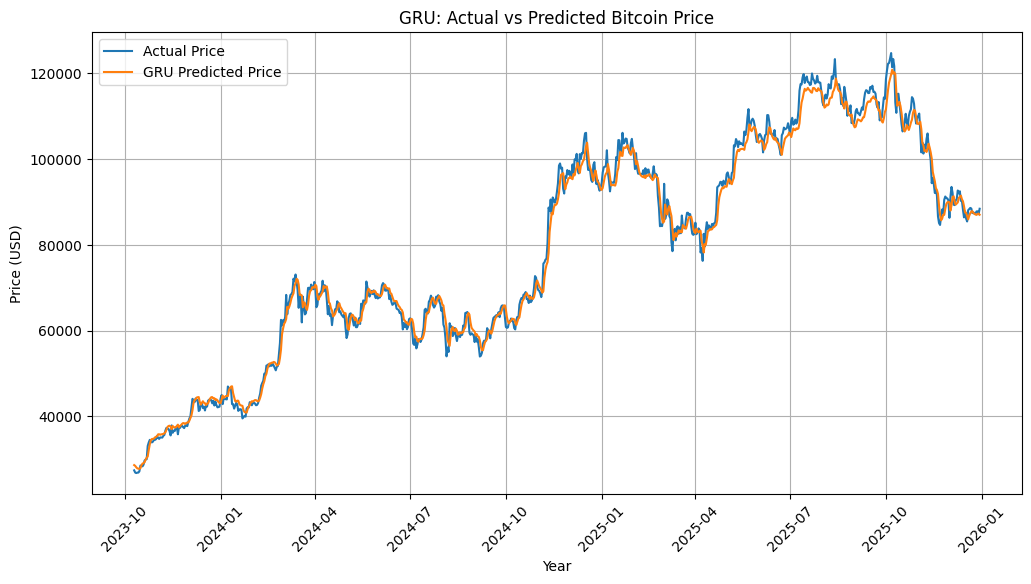

In [56]:
# Extract the corresponding dates for the GRU test dataset
test_dates_gru = df['Date'][-len(y_test_actual_gru):]

plt.figure(figsize=(12,6))

# Plot the actual Bitcoin prices from the test dataset
plt.plot(test_dates_gru, y_test_actual_gru, label='Actual Price')

# Plot the prices predicted by the GRU model
plt.plot(test_dates_gru, gru_predictions, label='GRU Predicted Price')

plt.title("GRU: Actual vs Predicted Bitcoin Price")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

GRU Forecast — 3 Months (90 Days)

In [57]:
# Define the no. of future time steps for forecasting (3 months ≈ 90 days)
gru_future_days_3m = 90

# Extract the last 60 observations from the scaled dataset
gru_last_sequence_3m = scaled_data[-lookback:]

# Create a list to store
gru_future_predictions_3m = []

# Copy the last sequence
gru_current_sequence_3m = gru_last_sequence_3m.copy()

# Generate predictions
for _ in range(gru_future_days_3m):

    # Reshape the sequence
    gru_input_seq = gru_current_sequence_3m.reshape(1, lookback, 1)

    # Predict the next time step
    gru_next_pred = gru_model.predict(gru_input_seq, verbose=0)

    # Store the predicted value
    gru_future_predictions_3m.append(gru_next_pred[0,0])

    # Update the sequence
    gru_current_sequence_3m = np.append(gru_current_sequence_3m[1:], gru_next_pred)

# Convert to Numpy Array
gru_future_predictions_3m = np.array(gru_future_predictions_3m).reshape(-1,1)

# Convert predicted values
gru_future_predictions_3m = scaler.inverse_transform(gru_future_predictions_3m)

GRU 3-Month Forecast Dates

In [58]:
gru_last_date_3m = df['Date'].iloc[-1]

# Generate a sequence of future dates for the next 90 days
gru_future_dates_3m = pd.date_range(
    start=gru_last_date_3m + pd.Timedelta(days=1),
    periods=gru_future_days_3m
)

Plot GRU 3-Month Forecast

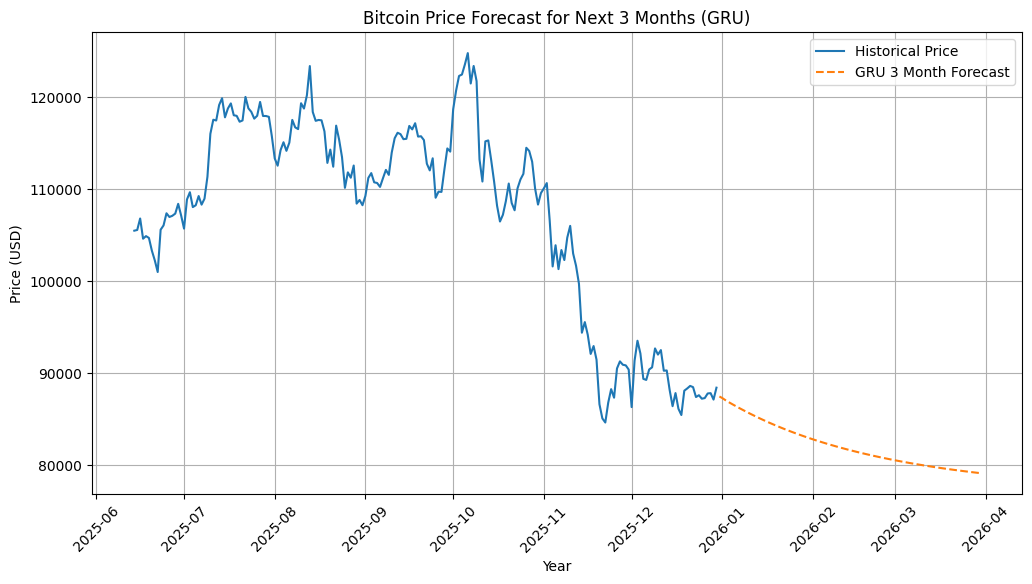

In [59]:
plt.figure(figsize=(12,6))

# Plot the recent historical Bitcoin prices (last 200 days)
plt.plot(df['Date'][-200:], df['Close'][-200:], label="Historical Price")

# Plot the GRU predicted prices for the next 3 months
plt.plot(gru_future_dates_3m, gru_future_predictions_3m,
         linestyle="--", label="GRU 3 Month Forecast")

plt.title("Bitcoin Price Forecast for Next 3 Months (GRU)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

# Display legend
plt.legend()

# Add gridlines
plt.grid(True)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

plt.show()

GRU 1-Year Forecast (365 Days)

In [60]:
# Define the forecast horizon for 1 Year
gru_future_days_1y = 365

# Extract the last 60 observations from the scaled dataset
gru_last_sequence_1y = scaled_data[-lookback:]

# Create a list to store
gru_future_predictions_1y = []

# Copy the last sequence
gru_current_sequence_1y = gru_last_sequence_1y.copy()

# Generate predictions
for _ in range(gru_future_days_1y):

    # Reshape the sequence
    gru_input_seq_1y = gru_current_sequence_1y.reshape(1, lookback, 1)

    # Predict the next future value
    gru_next_pred_1y = gru_model.predict(gru_input_seq_1y, verbose=0)

    # Store the predicted value
    gru_future_predictions_1y.append(gru_next_pred_1y[0,0])

    # Update the sequence for the next prediction
    gru_current_sequence_1y = np.append(gru_current_sequence_1y[1:], gru_next_pred_1y)

# Convert the list
gru_future_predictions_1y = np.array(gru_future_predictions_1y).reshape(-1,1)

# Convert predicted values back to the original Bitcoin price scale
gru_future_predictions_1y = scaler.inverse_transform(gru_future_predictions_1y)

GRU 1-Year Future Dates

In [61]:
gru_last_date_1y = df['Date'].iloc[-1]

# Generate a sequence of future dates starting from the next day
gru_future_dates_1y = pd.date_range(
    start=gru_last_date_1y + pd.Timedelta(days=1),
    periods=gru_future_days_1y
)

Plot GRU 1-Year Forecast

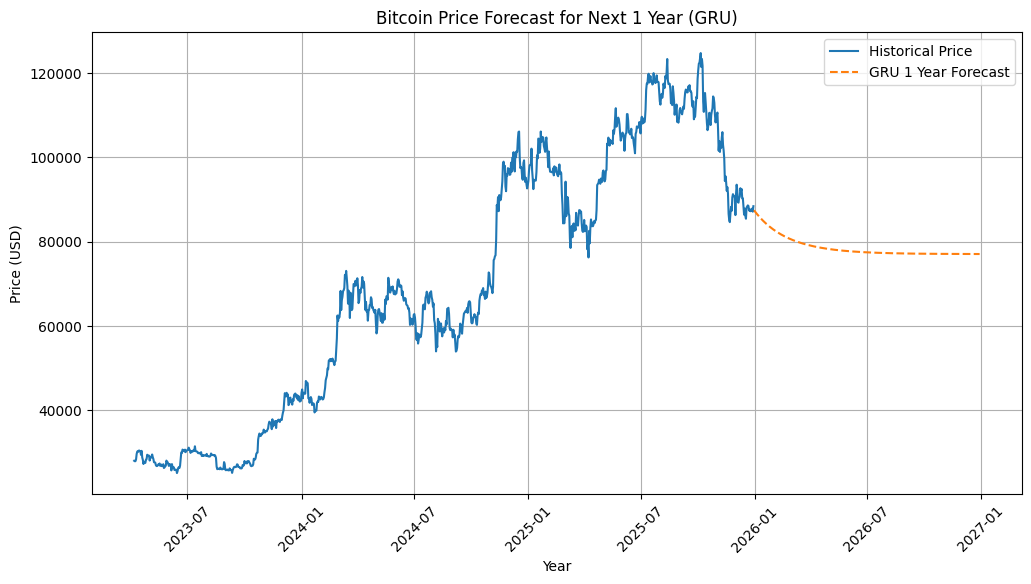

In [62]:
plt.figure(figsize=(12,6))

# Plot recent historical Bitcoin prices (last 1000 days)
plt.plot(df['Date'][-1000:], df['Close'][-1000:], label="Historical Price")

# Plot the predicted prices for the next 1 year generated by the GRU model
plt.plot(gru_future_dates_1y, gru_future_predictions_1y,
         linestyle="--", label="GRU 1 Year Forecast")

plt.title("Bitcoin Price Forecast for Next 1 Year (GRU)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

The trained LSTM and GRU deep learning models were used to forecast Bitcoin prices for both short-term (3 months) and long-term (1 year) horizons.

The LSTM model predicts a stable to slightly increasing trend, while the GRU model shows a strong downward trend. Overall, the LSTM model provides more stable and realistic forecasts compared to GRU.

TRANSFORMER-BASED TIME SERIES MODEL

Prepare Data

In [63]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Log transform
df['Close_log'] = np.log(df['Close'])

data_tf = df[['Close_log']].values

# Scaling
scaler_tf = MinMaxScaler(feature_range=(0,1))
scaled_data_tf = scaler_tf.fit_transform(data_tf)

Create Sequences

In [64]:
def create_sequences_tf(data, lookback=60):
    X_tf, y_tf = [], []
    for i in range(lookback, len(data)):
        X_tf.append(data[i-lookback:i, 0])
        y_tf.append(data[i, 0])
    return np.array(X_tf), np.array(y_tf)

lookback_tf = 60

X_tf, y_tf = create_sequences_tf(scaled_data_tf, lookback_tf)

# Reshape
X_tf = X_tf.reshape((X_tf.shape[0], X_tf.shape[1], 1))

Train-Test Split

In [65]:
split_tf = int(0.8 * len(X_tf))

X_train_tf, X_test_tf = X_tf[:split_tf], X_tf[split_tf:]
y_train_tf, y_test_tf = y_tf[:split_tf], y_tf[split_tf:]

Positional Encoding

In [66]:
import tensorflow as tf

def positional_encoding(length, d_model):
    positions = np.arange(length)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (dims//2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads, dtype=tf.float32)

Transformer Block

In [67]:
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, MultiHeadAttention, Add

def transformer_block_tf(x, head_size, num_heads, ff_dim, dropout=0.1):

    # Attention
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn = Dropout(dropout)(attn)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed Forward
    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1])(ff)

    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)

    return x

Build Transformer Model

In [68]:
from tensorflow.keras.layers import Input, GlobalAveragePooling1D
from tensorflow.keras.models import Model

input_tf = Input(shape=(X_train_tf.shape[1], 1))

# Project to higher dimension
x = Dense(32)(input_tf)

# Add positional encoding
pos_enc = positional_encoding(X_train_tf.shape[1], 32)
x = x + pos_enc

# Transformer blocks
x = transformer_block_tf(x, head_size=32, num_heads=4, ff_dim=64)
x = transformer_block_tf(x, head_size=32, num_heads=4, ff_dim=64)

# Pooling
x = GlobalAveragePooling1D()(x)

# Dense layers
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

output_tf = Dense(1)(x)

transformer_model = Model(input_tf, output_tf)

transformer_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

transformer_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 60, 32)    │         64 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 32)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 32)    │     16,800 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 60, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 60, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 60, 64)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 60, 32)    │      2,080 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 60, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 32)    │     16,800 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 60, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 60, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 32)    │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 60, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 60, 64)    │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 60, 32)    │      2,080 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 44,481 (173.75 KB)

 Trainable params: 44,481 (173.75 KB)

 Non-trainable params: 0 (0.00 B)

Train Transformer Model

In [85]:
history_tf = transformer_model.fit(
    X_train_tf,
    y_train_tf,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_tf, y_test_tf),
    verbose=1
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018 - val_loss: 2.6736e-04
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 6.2856e-04
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 2.9029e-04
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0017 - val_loss: 7.4126e-04
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 4.3152e-04
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 1.7287e-04
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0017 - val_loss: 2.8513e-04
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 9/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 6.8205e-04
Epoch 10/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 3.6319e-04
Epoch 11/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 8.2105e-04
Epoch 12/50


Epoch Plot (Transformer)

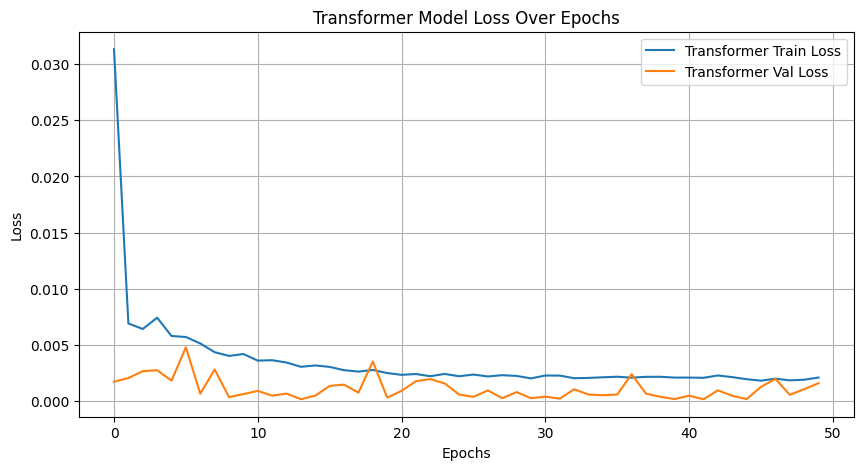

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_tf.history['loss'], label='Transformer Train Loss')
plt.plot(history_tf.history['val_loss'], label='Transformer Val Loss')

plt.title('Transformer Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

Predictions

In [87]:
tf_predictions = transformer_model.predict(X_test_tf)

# Inverse scaling & exp
tf_predictions = scaler_tf.inverse_transform(tf_predictions)
tf_predictions = np.exp(tf_predictions)

y_test_actual_tf = scaler_tf.inverse_transform(y_test_tf.reshape(-1,1))
y_test_actual_tf = np.exp(y_test_actual_tf)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Evaluation

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_tf = np.sqrt(mean_squared_error(y_test_actual_tf, tf_predictions))
mae_tf = mean_absolute_error(y_test_actual_tf, tf_predictions)
r2_tf = r2_score(y_test_actual_tf, tf_predictions)
mape_tf = np.mean(np.abs((y_test_actual_tf - tf_predictions) / y_test_actual_tf)) * 100

print("Transformer Results")
print("RMSE:", rmse_tf)
print("MAE:", mae_tf)
print("R2:", r2_tf)
print("MAPE:", mape_tf)

Transformer Results
RMSE: 15306.13208729357
MAE: 12351.2911645718
R2: 0.6373626717342296
MAPE: 13.522646306278304


Actual vs Predicted Plot

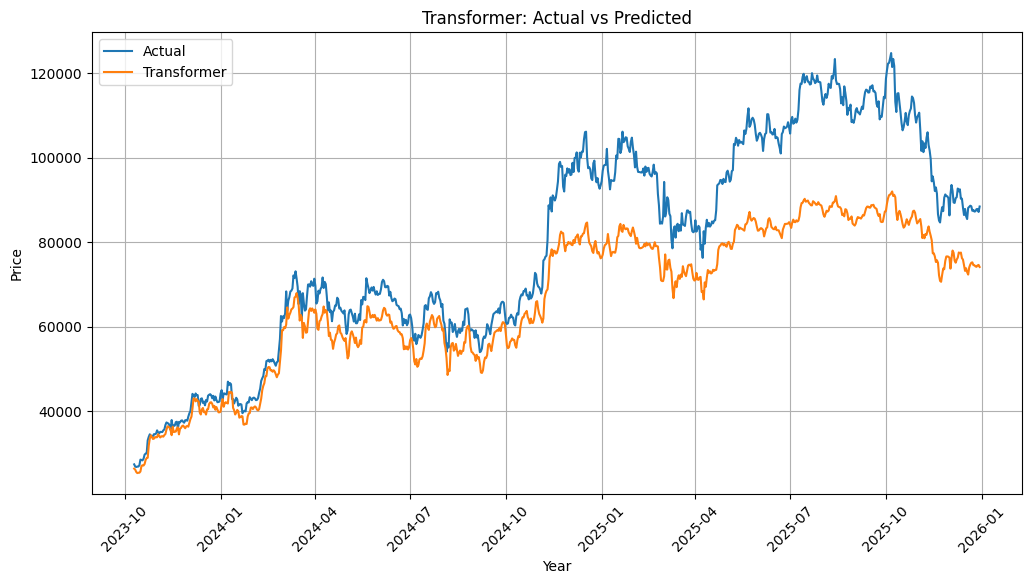

In [90]:
tf_dates = df['Date'][-len(y_test_actual_tf):]

plt.figure(figsize=(12,6))
plt.plot(tf_dates, y_test_actual_tf, label='Actual')
plt.plot(tf_dates, tf_predictions, label='Transformer')

plt.title("Transformer: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Price")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Forecast — 3 Months (90 Days) - Transformer Model

In [91]:
future_days_tf = 90

last_seq_tf = scaled_data_tf[-lookback_tf:]
future_preds_tf = []

current_seq_tf = last_seq_tf.copy()

for _ in range(future_days_tf):

    input_seq_tf = current_seq_tf.reshape(1, lookback_tf, 1)
    next_pred_tf = transformer_model.predict(input_seq_tf, verbose=0)

    # drift control
    next_pred_tf = next_pred_tf * 0.9 + current_seq_tf[-1] * 0.1

    future_preds_tf.append(next_pred_tf[0,0])

    current_seq_tf = np.append(current_seq_tf[1:], next_pred_tf)

3-Month Forecast Dates

In [92]:
future_preds_tf = np.array(future_preds_tf).reshape(-1,1)
future_preds_tf = scaler_tf.inverse_transform(future_preds_tf)
future_preds_tf = np.exp(future_preds_tf)

last_date_tf = df['Date'].iloc[-1]

future_dates_tf = pd.date_range(
    start=last_date_tf + pd.Timedelta(days=1),
    periods=future_days_tf
)

3-Month Forecast Plot - Transformer Model

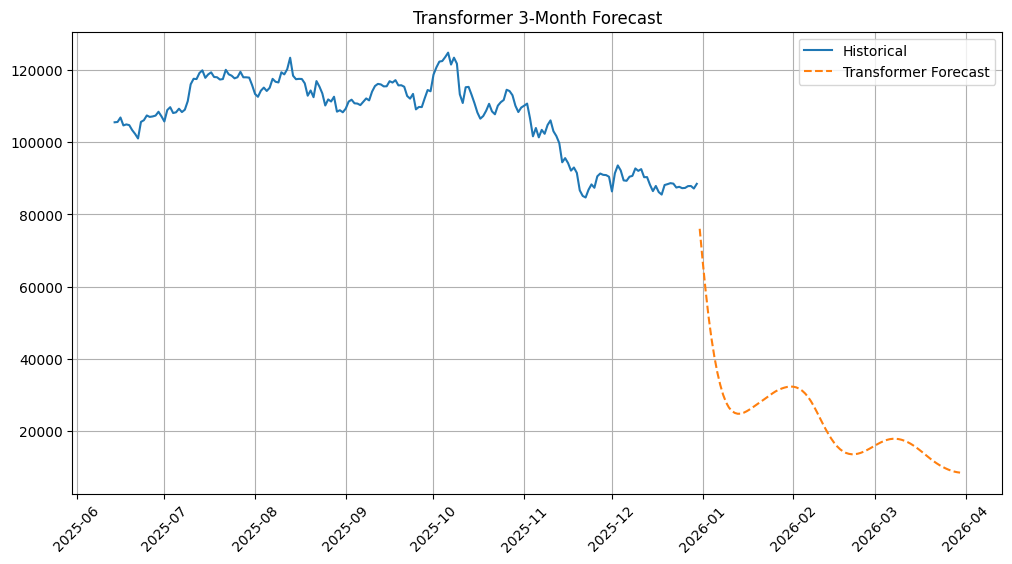

In [93]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'][-200:], df['Close'][-200:], label="Historical")
plt.plot(future_dates_tf, future_preds_tf, '--', label="Transformer Forecast")

plt.title("Transformer 3-Month Forecast")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

1-Year Forecast (365 Days) - Transformer Model

In [77]:
future_days_1y = 365

last_seq_1y = scaled_data_tf[-lookback_tf:]
future_preds_1y = []

current_seq_1y = last_seq_1y.copy()

for _ in range(future_days_1y):

    input_seq = current_seq_1y.reshape(1, lookback_tf, 1)
    next_pred = transformer_model.predict(input_seq, verbose=0)

    next_pred = next_pred * 0.9 + current_seq_1y[-1] * 0.1

    future_preds_1y.append(next_pred[0,0])

    current_seq_1y = np.append(current_seq_1y[1:], next_pred)

1-Year Future Dates

In [78]:
future_preds_1y = np.array(future_preds_1y).reshape(-1,1)
future_preds_1y = scaler_tf.inverse_transform(future_preds_1y)
future_preds_1y = np.exp(future_preds_1y)

future_dates_1y = pd.date_range(
    start=df['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=365
)

1-Year Forecast Plot - Transformer Model

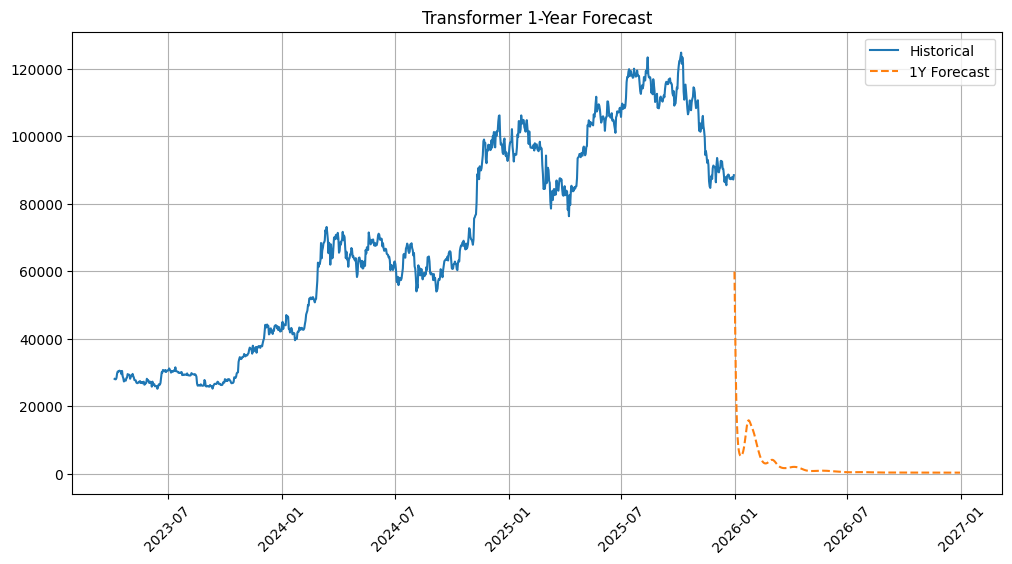

In [79]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'][-1000:], df['Close'][-1000:], label="Historical")
plt.plot(future_dates_1y, future_preds_1y, '--', label="1Y Forecast")

plt.title("Transformer 1-Year Forecast")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Model Performance Summary

The performance of different deep learning models was evaluated using RMSE, MAE, MAPE, and R² metrics.

- The LSTM model achieved strong performance with a low RMSE of 2855, MAE of 2216, MAPE of 3.01%, and a high R² value of 0.987, indicating accurate and reliable predictions.
- The GRU model slightly outperformed LSTM in terms of numerical metrics, achieving lower RMSE (2343), MAE (1770), and MAPE (2.27%), along with a higher R² value of 0.991.
- A tuned LSTM model, designed with increased complexity and additional layers, resulted in significantly worse performance, with very high RMSE (24091) and low R² (0.101).
- The Transformer model also underperformed, producing high error values and low predictive accuracy, indicating its inability to effectively capture the temporal dynamics of the dataset.

These results indicate that while both LSTM and GRU models are effective, simpler architectures tend to perform better than overly complex models for this dataset.

# Discussion on Model Complexity

Although the tuned LSTM and Transformer models used more complex architectures, they did not outperform the base LSTM and GRU models. This is likely due to overfitting, limited data for training deeper models, and high noise in financial time series.

Overall, increased complexity did not improve performance and reduced generalisation. In contrast, the base LSTM model provided more stable and reliable predictions, making it more suitable for forecasting.

# Future Forecast using LSTM Model

The LSTM model was used to generate multi-step forecasts for Bitcoin prices over future time horizons.

A recursive forecasting approach was applied, where each predicted value is fed back into the model to generate the next prediction. This method simulates real-world forecasting conditions.

Forecast Code (3-Month Forecast)

In [81]:
# Number of future days (3 months ≈ 90 days)
future_days = 90

# Get last 60 days
last_sequence = scaled_data[-lookback:]

# Store predictions
future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    # Reshape input
    input_seq = current_sequence.reshape(1, lookback, 1)

    # Predict next value
    next_pred = model.predict(input_seq, verbose=0)

    future_predictions.append(next_pred[0,0])

    # Update sequence
    current_sequence = np.append(current_sequence[1:], next_pred)

# Convert to array
future_predictions = np.array(future_predictions).reshape(-1,1)

# Inverse scaling
future_predictions = scaler.inverse_transform(future_predictions)

# Generate future dates
last_date = df['Date'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_days
)

In [83]:
# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Price': future_predictions.flatten()
})

# Set Date as index
forecast_df.set_index('Date', inplace=True)

print("\n Forecast Generated using LSTM Model")
print(" Duration: Next 90 Days")

print(forecast_df.head(90))


 Forecast Generated using LSTM Model
 Duration: Next 90 Days
            Predicted_Price
Date                       
2025-12-31     88208.898438
2026-01-01     88370.054688
2026-01-02     88559.898438
2026-01-03     88763.429688
2026-01-04     88971.820312
...                     ...
2026-03-26     93855.343750
2026-03-27     93862.601562
2026-03-28     93869.570312
2026-03-29     93876.250000
2026-03-30     93882.664062

[90 rows x 1 columns]


In [84]:
# First 30 days forecast
forecast_30 = forecast_df.head(30)

print("\n 30-Day Forecast using LSTM Model")
print(" Duration: Next 30 Days")

print(forecast_30)


 30-Day Forecast using LSTM Model
 Duration: Next 30 Days
            Predicted_Price
Date                       
2025-12-31     88208.898438
2026-01-01     88370.054688
2026-01-02     88559.898438
2026-01-03     88763.429688
2026-01-04     88971.820312
2026-01-05     89179.734375
2026-01-06     89383.734375
2026-01-07     89581.609375
2026-01-08     89771.968750
2026-01-09     89953.945312
2026-01-10     90127.132812
2026-01-11     90291.460938
2026-01-12     90447.093750
2026-01-13     90594.390625
2026-01-14     90733.812500
2026-01-15     90865.937500
2026-01-16     90991.335938
2026-01-17     91110.585938
2026-01-18     91224.265625
2026-01-19     91332.875000
2026-01-20     91436.906250
2026-01-21     91536.742188
2026-01-22     91632.742188
2026-01-23     91725.179688
2026-01-24     91814.296875
2026-01-25     91900.296875
2026-01-26     91983.312500
2026-01-27     92063.484375
2026-01-28     92140.875000
2026-01-29     92215.585938


# Conclusion

This Project analysed Bitcoin price data from 2014 to 2025 and applied multiple machine learning and deep learning models for time series forecasting.

Both LSTM and GRU demonstrated strong predictive capabilities; however, LSTM emerged as the most suitable model due to its stability and consistent forecasting behaviour.

Additionally, increasing model complexity through tuned LSTM and Transformer models did not improve performance, highlighting the importance of model selection over complexity.

Overall, the LSTM model proved to be a robust and effective approach for financial time series forecasting, producing stable and realistic predictions.